In [23]:
from typing import List
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

from ccxt.lighter import lighter

from siglab_py.util.market_data_util import fetch_candles
from siglab_py.util.analytic_util import compute_candles_stats

In [24]:
start_date = datetime(2026, 3,20)
end_date = datetime(2026,3,30,14,0,0)
exchange = lighter()
ticker = "BTC/USDC:USDC"

### Fetch candles

In [25]:
candles = fetch_candles(
                                                start_ts=int(start_date.timestamp()), 
                                                end_ts=int(end_date.timestamp()), 
                                                exchange=exchange, normalized_symbols=[ticker], 
                                                candle_size = '1h', 
                                                num_candles_limit = 100,
                                                logger = None
                                            )
pd_candles = candles[ticker]

c:\programdata\anaconda3\envs\py3_12\lib\site-packages\siglab_py\util\market_data_util.py:342: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  num_rows_with_expected_gap = pd_candles[~pd_candles.timestamp_ms_gap.isna()][pd_candles.timestamp_ms_gap==timestamp_ms_gap_median].shape[0]


### compute TA

In [26]:
compute_candles_stats(
            pd_candles=pd_candles,
            boillenger_std_multiples=2,
            sliding_window_how_many_candles=24,
            pypy_compat=False # Slopes calculation? Set pypy_compat to False
        )

c:\programdata\anaconda3\envs\py3_12\lib\site-packages\siglab_py\util\market_data_util.py:342: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  num_rows_with_expected_gap = pd_candles[~pd_candles.timestamp_ms_gap.isna()][pd_candles.timestamp_ms_gap==timestamp_ms_gap_median].shape[0]
c:\programdata\anaconda3\envs\py3_12\lib\site-packages\siglab_py\util\analytic_util.py:576: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pd_candles['ema_rsi'] = pd_candles['rsi'].ewm(
c:\programdata\anaconda3\envs\py3_12\lib\site-packages\siglab_py\util\analytic_util.py:581: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns a

In [27]:
pd_candles = pd_candles.iloc[-24:]

In [28]:
pd_candles[['datetime', 'close', 'normalized_ema_long_slope']]

,datetime,close,normalized_ema_long_slope
232,2026-03-29 16:00:00,66682.4,0.067270
233,2026-03-29 17:00:00,66590.3,0.072078
234,2026-03-29 18:00:00,66474.0,0.070001
235,2026-03-29 19:00:00,66778.6,0.064101
236,2026-03-29 20:00:00,66822.6,0.055157
237,2026-03-29 21:00:00,66553.6,0.043878
238,2026-03-29 22:00:00,66563.6,0.027982
239,2026-03-29 23:00:00,66500.6,0.010420
240,2026-03-30 00:00:00,66462.7,-0.011912
241,2026-03-30 01:00:00,66341.6,-0.046202


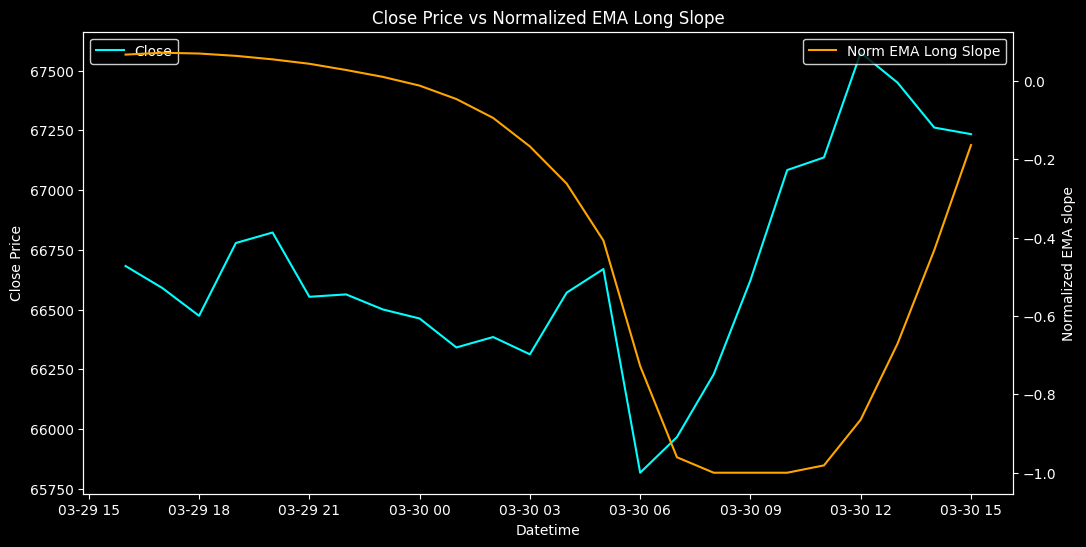

In [31]:
selected = pd_candles[['datetime', 'close', 'normalized_ema_long_slope']]

plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(12, 6), facecolor='black')
ax1.set_facecolor('black')

ax1.set_xlabel('Datetime', color='white')
ax1.set_ylabel('Close Price', color='white')
ax1.plot(selected['datetime'], selected['close'], color='cyan', label='Close')
ax1.tick_params(axis='y', colors='white')
ax1.tick_params(axis='x', colors='white')
ax1.legend(loc='upper left', facecolor='black', edgecolor='white')

ax2 = ax1.twinx()
ax2.set_ylabel('Normalized EMA slope', color='white')
ax2.plot(selected['datetime'], selected['normalized_ema_long_slope'], color='orange', label='Norm EMA Long Slope')
ax2.tick_params(axis='y', colors='white')
ax2.legend(loc='upper right', facecolor='black', edgecolor='white')

plt.title('Close Price vs Normalized EMA Long Slope', color='white')
plt.show()